#### imports

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from matplotlib import colormaps
import os
from pathlib import Path
import pandas as pd
from typing import List
from dataclasses import replace
import utils_bone
import get_images_and_metadata as iam
import resolution_theory as thc
import plotting_func as pu
import sweep_func as sp
import mean_free_path_func as mfp
import utils_microscope
from utils_microscope import STEMInputs

#### STEMInput parameters for the microscope and sample.

In [2]:
inp = STEMInputs(
        matrix="water",
        obj="bone",
        t=500e-9,  # matrix thickness [m]
        t_SiN=50e-9,  # SiN window [m]
        z_rel=1.0,  # object at the bottom window (0=bottom, 0.5=middle, 1=top)
        x=200e-9,  # lamella thickness
        U_eV=200_000,  # accelerating voltage [eV]
        Cs_m=2.7e-3,  # spherical aberration [m]
        alpha_p=1.7e-3,  # probe semi convergence angle
        beta_rad=0.025,  # detector semic convergence angle
        eD_m2=1 * 1e20  # dose = 1 e-/Å²
)
T_tot = (inp.t + inp.x + 2 * inp.t_SiN) * 1e9

In [3]:
# theoretical resolution for the chosen convergence angle (alpha_p)
EE = inp.e * inp.U_eV
E0 = inp.m0 * (inp.c ** 2)
lam = inp.h * inp.c / np.sqrt(2 * EE * E0 + EE ** 2)
theor_res = 1e-3 * lam / (2 * (inp.alpha_p * 1e-3))
print(f"the theoretical resolution is {theor_res * 1e9:.2f} nm")

the theoretical resolution is 0.74 nm


#### This function takes STEMInput parameters and a range of sample thicknesses and and returns the expected STEM resolution.
STEM resolution is a sum of SNR limited resolution, beam broadening limited resolution, and probe size limit. 
STEM resolution computations are in accordance with de Jonge 2018 - "Theory of the spatial resolution of (scanning) transmission electron
microscopy in liquid water or ice layers" - Ultramicroscopy 187 (2018) 113–125.
##### when copying sweep for another paramter, be sure to change the inp replacement line
##### t_i is specific to sweep function for thickness due to different layers

In [4]:
def sweep(inp: STEMInputs, range):

    vals = np.asarray(range, dtype=float)
    n = vals.size
    dSTEM = np.empty(n);
    dSNR = np.empty(n);
    dBlur = np.empty(n);
    d50 = np.empty(n);
    regime = np.empty(n, dtype=object)
    mfp_values = np.empty(n);

    for i, j in enumerate(vals):
        
        #------ part specific to thickness sweep due to different layers
        t_i = j - float(inp.x) - 2.0 * float(inp.t_SiN)
        if t_i < 0:
            dSTEM[i] = dSNR[i] = dBlur[i] = d50[i] = np.nan
            regime[i] = "BF/DF?"
            continue
        #---------------------------------------------------------------

        inpi = replace(inp, t=t_i)
        out = thc.compute_stem_resolution_for_beta(inpi) # compute resolution
        l_b, l_m, l_SiN, l_o = mfp.mean_free_path(inpi) # compute mfp
        l_eff = mfp.compute_effective_mfp(inp.t, inp.x, inp.t_SiN, l_b, l_m, l_SiN)
        dSTEM[i] = out["dSTEM_nm"];
        dSNR[i] = out["dSNR_nm"];
        dBlur[i] = out["dblur_nm"];
        d50[i] = out["d50_nm"];
        regime[i] = out["regime"]
        mfp_values[i] = l_eff * 1e9
    return {"x_field": "thickness_nm", "x": vals * 1e9, "dSTEM": dSTEM, "dSNR": dSNR, "dBlur": dBlur, "d50": d50,
                "regime": regime, "mfp": mfp_values}

In [5]:
# for thickness range get STEM resolution 
Ttot_nm = np.linspace((inp.x + 2 * inp.t_SiN), (1200 * 1e-9), 60)
res = sweep(inp, Ttot_nm)

#### plot

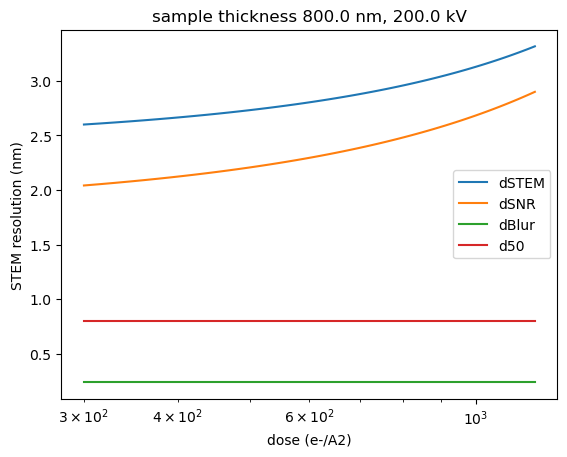

In [6]:
plt.figure()
plt.plot(res["x"], res["dSTEM"])
plt.plot(res["x"], res["dSNR"])
plt.plot(res["x"], res["dBlur"])
plt.plot(res["x"], res["d50"])
plt.title(f"sample thickness {T_tot} nm, {inp.U_eV * 1e-3} kV")
plt.xlabel("dose (e-/A2)"), plt.ylabel("STEM resolution (nm)")
plt.xscale('log')
plt.legend(['dSTEM','dSNR','dBlur','d50'])

#### for saving a .txt file with STEMInput parameters as a header

In [7]:
# --- build a simple flat metadata dict from STEMInputs ---
from dataclasses import asdict
import json

inp_dict = asdict(inp)
clean = {}
for k, v in inp_dict.items():
    # numpy numeric types -> python floats
    if isinstance(v, (np.floating, np.integer)):
        clean[k] = float(v)
    # arrays / lists -> JSON string
    elif isinstance(v, (list, tuple, np.ndarray)):
        clean[k] = json.dumps(np.asarray(v).tolist())
    else:
        clean[k] = v

# add convenient unit-converted fields
clean['U_kV'] = float(inp.U_eV) / 1e3
clean['x_nm'] = float(inp.x) * 1e9
clean['t_nm'] = float(inp.t) * 1e9
clean['t_SiN_nm'] = float(inp.t_SiN) * 1e9
clean['alpha_mrad'] = float(inp.alpha_p) * 1e3
clean['dose_ePerA2'] = float(inp.eD_m2) * 1e-20

# save resolution with a single metadata header (metadata appears once at top of file)
df_res = pd.DataFrame(res)
out_file_thick = Path(f"res_vs_thick_kV{int(clean['U_kV'])}kV.txt")
with open(out_file_thick, 'w', encoding='utf8', newline='') as fh:
    fh.write("# Generated by theory.py\n")
    fh.write("# STEMInputs metadata:\n")
    for k, v in clean.items():
        fh.write(f"# {k} = {v}\n")
    fh.write("#\n")
    df_res.to_csv(fh, sep='\t', index=False, float_format='%.6f')
print(f"Saved: {out_file_thick.resolve()}")

Saved: C:\Users\z924214\OneDrive - Radboudumc\TEM\Image metrics\codes\res_vs_thick_kV200kV.txt


### STEM resolution for thickness and dose grid
 these cells returns a plot a heatmap for a 2D array of STEM resolution for grid of sample thicknesses and electron doses

In [8]:
# create vectors of ranges and a grid from them
# thickness in nm
# electron doses in e-/A2
T_range = np.linspace((inp.x + 2 * inp.t_SiN) * 1e9, 1200, 10)  # thickness from 100 nm to 1000 nm
D_range = np.logspace(-1, 1, 20)     # dose from 0.01 to 100

In [9]:
# this function gets a range of thicknesses (nm) and doses (e-/A2) 
# returns arrays (nm) of computed total STEM resolution, SNR-limited, broadening limited, proble limited (according to de Jonge 2018)

def res_nm(t_nm, d_A2):
    
    t_i = t_nm - float(inp.x) - 2.0 * float(inp.t_SiN)
    inpi = replace(inp, t=float(t_i)*1e-9, eD_m2=float(d_A2)*1e20)

    out = thc.compute_stem_resolution_for_beta(inpi) # compute resolution
    l_b, l_m, l_SiN, l_o = mfp.mean_free_path(inpi) # compute mfp
    l_eff = mfp.compute_effective_mfp(inpi.x, inpi.t, inpi.t_SiN, l_b, l_m, l_SiN) # compute effective mfp
    
    dSTEM = float(out["dSTEM_nm"])
    dSNR  = float(out["dSNR_nm"])
    dBlur = float(out["dblur_nm"])
    d50   = float(out["d50_nm"])
    regime = out["regime"]
    mfp_nm = float(l_eff * 1e9)
    
    return dSTEM, dSNR, dBlur, d50, regime, mfp_nm

In [10]:
# create 2D array of thicknesses and doses and compute resolutions for every combination
T, D = np.meshgrid(T_range, D_range, indexing='ij')
vres = np.vectorize(res_nm, otypes=[float, float, float, float, object, float])
dSTEM, dSNR, dBlur, d50, regime, mfp_nm = vres(T, D)

Decide what R you want to plot and the upper limit

In [11]:
# R can be dSTEM, dSNR, dBlur, d50, mpf_nm
R = dSTEM
# optional: set an upper limit for STEM resolution
limR = 10.0
dSTEM[dSTEM > limR] = np.nan

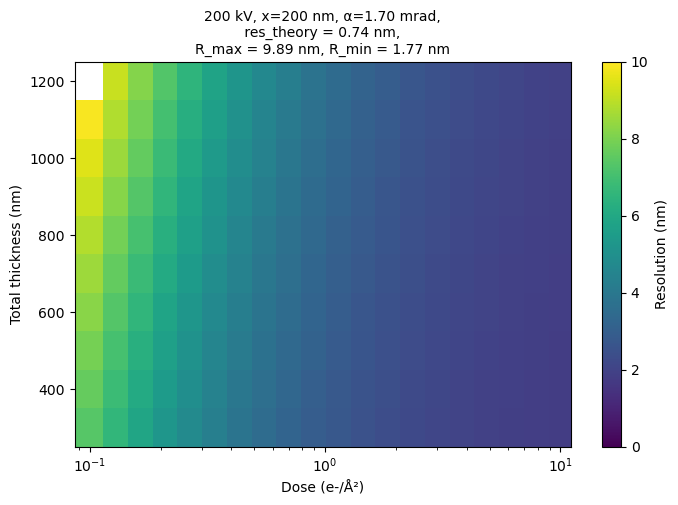

In [12]:
# make and display a heatmap of resolution (R) vs dose and thickness

fig, ax = plt.subplots(figsize=(8,5))
c = ax.pcolormesh(D_range, T_range, R, shading='auto', cmap='viridis', vmin=0, vmax=limR) #vmax is the set upper resolution limit
ax.set_xscale('log')
ax.set_xlabel('Dose (e-/Å²)')
ax.set_ylabel('Total thickness (nm)')
fig.colorbar(c, ax=ax, label='Resolution (nm)')
ax.set_title(f"{inp.U_eV/1e3:.0f} kV, x={inp.x*1e9:.0f} nm, α={inp.alpha_p*1e3:.2f} mrad,\n "
                  f"res_theory = {(theor_res * 1e9):.2f} nm, \n"
             f"R_max = {np.nanmax(R):.2f} nm, R_min = {np.nanmin(R):.2f} nm",
                  fontsize = 10)
plt.show()